In [ ]:
!pip install transformers torch
from transformers import pipeline

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [ ]:
from transformers import pipeline
senti = pipeline('sentiment-analysis')
reviews = [
'This movie was absolutely breathtaking! A masterpiece.',
'Terrible acting, boring plot. Wasted 2 hours of my life.',
'It was okay. Nothing special but not bad either.',
'Shah Rukh Khan was brilliant. Loved every minute!',
'Ram is more attractive than vishnu ani evaro chepparu',
'KSRM is a great college in asia',
'nalini is bad '
]
results = senti(reviews) # pass a list — processes all at once
for review, result in zip(reviews, results):
  label = result['label'] # 'POSITIVE' or 'NEGATIVE'
  score = result['score'] # confidence: 0.0 to 1.0
  print(f'{label} ({score:.1%}) | {review[:50]}...')
# POSITIVE (99.8%) | This movie was absolutely breathtaking! A masterp...
# NEGATIVE (99.9%) | Terrible acting, boring plot. Wasted 2 hours of m...
# NEGATIVE (55.2%) | It was okay. Nothing special but not bad either....
# POSITIVE (99.1%) | Shah Rukh Khan was brilliant. Loved every minute!.

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


POSITIVE (100.0%) | This movie was absolutely breathtaking! A masterpi...
NEGATIVE (100.0%) | Terrible acting, boring plot. Wasted 2 hours of my...
POSITIVE (99.6%) | It was okay. Nothing special but not bad either....
POSITIVE (100.0%) | Shah Rukh Khan was brilliant. Loved every minute!...
POSITIVE (99.9%) | Ram is more attractive than vishnu ani evaro chepp...
POSITIVE (100.0%) | KSRM is a great college in asia...
NEGATIVE (100.0%) | nalini is bad ...


In [ ]:
from transformers import pipeline
# Zero-shot: classify without any task-specific training
classifier = pipeline('zero-shot-classification',
model='facebook/bart-large-mnli')
text = 'ksrm is a college of engineering . in aiml we have best students in non crt but cse are worst except few(nen itey aswitha ni analey)'
labels = ['technology','course','computer science','artificial intellignece']
result = classifier(text, candidate_labels=labels)
for label, score in zip(result['labels'], result['scores']):
   print(f'{label:15} {score:.1%}')


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

technology      57.7%
course          28.7%
artificial intellignece 10.7%
computer science 2.9%


In [ ]:
import transformers
print(transformers.__file__)
print(transformers.__version__)

/usr/local/lib/python3.12/dist-packages/transformers/__init__.py
4.44.2


In [1]:
!pip install --force-reinstall transformers==4.44.2 tokenizers==0.19.1 --break-system-packages

  Using cached transformers-4.44.2-py3-none-any.whl.metadata (43 kB)
  Using cached tokenizers-0.19.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
  Using cached filelock-3.29.4-py3-none-any.whl.metadata (2.0 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached numpy-2.4.6-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached regex-2026.5.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached safetensors-0.8.0-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.2 kB)
  Using cached tqdm-4.68.2-py3-none-any.whl.metadata (58 kB)
  Using cached fsspec-

In [ ]:
from transformers import pipeline

summariser = pipeline(
    task="summarization",
    model="facebook/bart-large-cnn"
)

long_text = """
The Indian Space Research Organisation (ISRO) successfully launched its
latest Earth observation satellite from the Satish Dhawan Space Centre in
Sriharikota. The satellite carries high-resolution cameras capable of
imaging at 0.5-metre resolution, making it among the most advanced Earth
observation tools deployed. The data will be used for agriculture
monitoring, disaster management, and urban planning.
"""

summary = summariser(
    long_text,
    max_length=20,
    min_length=15,
    do_sample=False,
    truncation=True
)

print(summary[0]["summary_text"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


The Indian Space Research Organisation (ISRO) successfully launched its latest Earth observation satellite.


In [2]:
from transformers import pipeline
qa = pipeline('question-answering',
model='deepset/bert-base-cased-squad2')
context = '''
Sachin Tendulkar played for India for 24 years from 1989 to 2013.
He scored 100 international centuries and 15,921 Test runs.
He was awarded the Bharat Ratna in 2014.
'''
questions = [
'How many international centuries did Sachin score?',
'When did Sachin Tendulkar retire?',
'What award did he receive in 2014?',
]
for q in questions:
  answer = qa(question=q, context=context)
  print(f'Q: {q}')
  print(f'A: {answer["answer"]} (confidence: {answer["score"]:.1%})')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Some weights of the model checkpoint at deepset/bert-base-cased-squad2 were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/152 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Q: How many international centuries did Sachin score?
A: 100 (confidence: 95.2%)
Q: When did Sachin Tendulkar retire?
A: 2013 (confidence: 67.0%)
Q: What award did he receive in 2014?
A: Bharat Ratna (confidence: 97.4%)


In [3]:
from transformers import (AutoTokenizer,
AutoModelForSequenceClassification,
TrainingArguments, Trainer)
from datasets import Dataset
# --- Step 1: Prepare your labelled dataset ---
texts = ['Great film!', 'Terrible movie.', 'Average, nothing special.',
'Best film of the year!', 'Waste of time and money.']
labels = [1, 0, 0, 1, 0] # 1 = positive, 0 = negative
# --- Step 2: Load tokeniser ---
# 'bert-base-uncased' = lowercase BERT, 110M parameters
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
def tokenise(batch):
# padding=True: pad shorter sequences to the longest in the batch
# truncation=True: cut sequences longer than max_length
  return tokenizer(batch['text'], padding=True,
truncation=True, max_length=128)
dataset = Dataset.from_dict({'text': texts, 'label': labels})
dataset = dataset.map(tokenise, batched=True)
# --- Step 3: Load pre-trained BERT + classification head ---
# num_labels=2 adds a 2-class head on top of BERT's [CLS] output
model = AutoModelForSequenceClassification.from_pretrained(
'bert-base-uncased', num_labels=2
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/5 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [4]:
# --- Step 4: Define training configuration ---
args = TrainingArguments(
output_dir = './results',
num_train_epochs = 3, # 3 passes through training data
per_device_train_batch_size = 4, # process 4 examples at a time
learning_rate = 2e-5, # small LR — avoid forgetting pre-training
logging_steps = 10,
save_strategy = 'no',
)
# --- Step 5: Train ---
trainer = Trainer(
model = model,
args = args,
train_dataset = dataset,
)
trainer.train() # fine-tunes BERT on your labelled data
# --- Step 6: Save and reload as a pipeline ---
model.save_pretrained('./my_sentiment_model')
tokenizer.save_pretrained('./my_sentiment_model')
# Use your custom fine-tuned model exactly like any other pipeline
from transformers import pipeline
my_pipeline = pipeline('sentiment-analysis', model='./my_sentiment_model')
print(my_pipeline('This Bollywood film was a pure delight!'))
# [{'label': 'LABEL_1', 'score': 0.97}] -> LABEL_1 = positive

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


[{'label': 'LABEL_1', 'score': 0.6069448590278625}]


LAB

In [6]:
import pandas as pd
from transformers import pipeline
reviews_data = [
# Bollywood
{'movie': '3 Idiots', 'source': 'Bollywood',
'review': 'An absolute masterpiece! Makes you laugh and cry. '
'Aamir Khan delivers one of his finest performances ever.'},
{'movie': '3 Idiots', 'source': 'Bollywood',
'review': 'Overrated and preachy. The message was fine but '
'execution felt too theatrical and unrealistic.'},
{'movie': 'Dangal', 'source': 'Bollywood',
'review': 'Incredibly inspiring! Geeta and Babita brought tears '
'to my eyes. Best sports film ever made in India.'},
{'movie': 'Dangal', 'source': 'Bollywood',
'review': 'Good film but very long. Some scenes dragged unnecessarily.'},
# Hollywood
{'movie': 'Inception', 'source': 'Hollywood',
'review': 'Mind-bending and visually stunning. Nolan at his absolutebest.'},
{'movie': 'Inception', 'source': 'Hollywood',
'review': 'Too complicated. I had no idea what was happening half thetime.'},
{'movie': 'Parasite', 'source': 'Hollywood',
'review': 'Perfect film. The class commentary is brilliant. Deserved everyOscar.'},
{'movie': 'Parasite', 'source': 'Hollywood',
'review': 'I expected more from an Oscar winner. Ending felt rushed.'},
]
df = pd.DataFrame(reviews_data)

In [7]:
# Load once — not inside a loop (that would reload weights every iteration)
sentiment = pipeline('sentiment-analysis',
model='distilbert-base-uncased-finetuned-sst-2-english')
# Batch all reviews at once — faster than one-by-one
results = sentiment(df['review'].tolist())
df['sentiment'] = [r['label'] for r in results] # POSITIVE / NEGATIVE
df['confidence'] = [r['score'] for r in results] # 0.0 to 1.0
# sentiment_score: 1.0 = very positive, 0.0 = very negative
df['sentiment_score'] = df['confidence'].where(
df['sentiment'] == 'POSITIVE',
1 - df['confidence']
)
print(df[['movie','sentiment','confidence']].to_string(index=False))

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


    movie sentiment  confidence
 3 Idiots  POSITIVE    0.999879
 3 Idiots  NEGATIVE    0.999016
   Dangal  POSITIVE    0.999878
   Dangal  NEGATIVE    0.992343
Inception  POSITIVE    0.999849
Inception  NEGATIVE    0.999590
 Parasite  POSITIVE    0.999857
 Parasite  NEGATIVE    0.998913


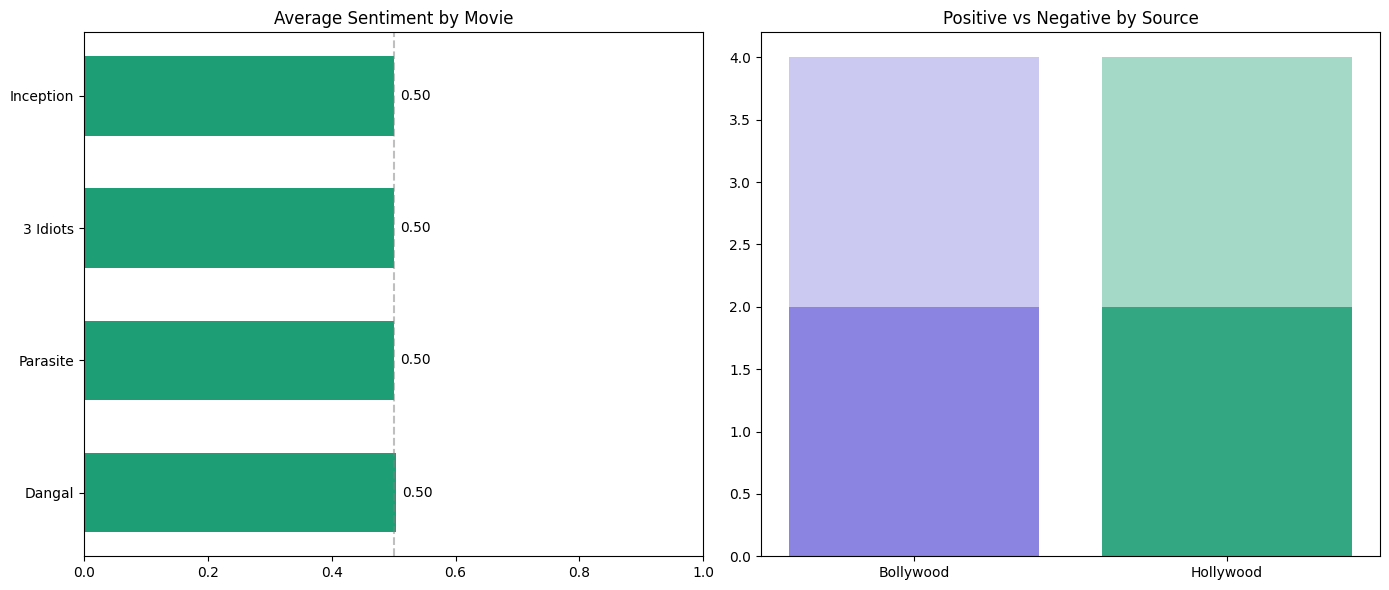

In [8]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Chart 1: Average sentiment score per movie
ax1 = axes[0]
movie_scores =df.groupby('movie')['sentiment_score'].mean().sort_values(ascending=False)
colours = ['#1D9E75' if v >= 0.5 else '#D85A30' for v in
movie_scores.values]
bars = ax1.barh(movie_scores.index, movie_scores.values, color=colours,
height=0.6)
ax1.set_xlim(0, 1)
ax1.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax1.set_title('Average Sentiment by Movie')
for bar, val in zip(bars, movie_scores.values):
  ax1.text(val+0.01, bar.get_y()+bar.get_height()/2, f'{val:.2f}',
  va='center')
# Chart 2: Positive vs Negative split by source
  ax2 = axes[1]
for source, colour in [('Bollywood','#7F77DD'), ('Hollywood','#1D9E75')]:
  subset = df[df['source'] == source]
  pos = (subset['sentiment']=='POSITIVE').sum()
  neg = (subset['sentiment']=='NEGATIVE').sum()
  ax2.bar(source, pos, color=colour, alpha=0.9)
  ax2.bar(source, neg, bottom=pos, color=colour, alpha=0.4)
  ax2.set_title('Positive vs Negative by Source')
plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
def analyse_review(review_text, movie_name='Unknown'):
  result = sentiment(review_text)[0]
  label = result['label']
  conf = result['score']
  if label == 'POSITIVE':
    score = conf
    verdict = 'LOVED IT' if conf > 0.95 else 'LIKED IT'
  else:
    score = 1 - conf
    verdict = 'HATED IT' if conf > 0.95 else 'DISLIKED IT'
  print(f'Movie : {movie_name}')
  print(f'Verdict : {verdict}')
  print(f'Score : {score:.1%} positive')
  print(f'Review : {review_text[:80]}...')
  return {'movie': movie_name, 'verdict': verdict, 'score': score}
analyse_review(
'Rajkummar Rao was phenomenal. A raw, honest performance. '
'Easily the best Hindi film of the decade.',
'Stree'
)

Movie : Stree
Verdict : LOVED IT
Score : 100.0% positive
Review : Rajkummar Rao was phenomenal. A raw, honest performance. Easily the best Hindi f...


{'movie': 'Stree', 'verdict': 'LOVED IT', 'score': 0.9998749494552612}